In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from database import get_engine

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import xgboost as xgb

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")

All imports successful!


In [2]:
engine = get_engine()

df = pd.read_sql("""
    SELECT *
    FROM factors
    ORDER BY ticker, date
""", engine)

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['ticker', 'date']).reset_index(drop=True)

# Create target variable - did this stock beat the average next month?
df['next_month_return'] = df.groupby('ticker')['daily_return'].shift(-21)

df['target'] = (
    df['next_month_return'] > df.groupby('date')['next_month_return'].transform('mean')
).astype(int)

df = df.dropna()

print(f"Total rows: {len(df):,}")
print(f"Target distribution:")
print(df['target'].value_counts())
print(f"\nBuy signals (1): {df['target'].mean()*100:.1f}%")
print(f"Avoid signals (0): {(1-df['target'].mean())*100:.1f}%")

Total rows: 37,410
Target distribution:
target
0    19229
1    18181
Name: count, dtype: int64

Buy signals (1): 48.6%
Avoid signals (0): 51.4%


In [3]:
FEATURES = [
    'mom_12m', 'mom_6m', 'mom_1m', 'mom_5d', 'reversal',
    'vol_21d', 'vol_63d', 'vol_ratio',
    'volume_ratio', 'pvt',
    'dist_from_high', 'rsi'
]

X = df[FEATURES]
y = df['target']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature list: {FEATURES}")

Features shape: (37410, 12)
Target shape: (37410,)

Feature list: ['mom_12m', 'mom_6m', 'mom_1m', 'mom_5d', 'reversal', 'vol_21d', 'vol_63d', 'vol_ratio', 'volume_ratio', 'pvt', 'dist_from_high', 'rsi']


In [5]:
df_ml = df.copy()
df_ml = df_ml.sort_values('date').reset_index(drop=True)

train_years = list(range(2015, 2020))
test_years  = list(range(2020, 2025))

all_predictions = []

for test_year in test_years:
    train_mask = df_ml['date'].dt.year < test_year
    test_mask  = df_ml['date'].dt.year == test_year
    
    X_train = df_ml[train_mask][FEATURES]
    y_train = df_ml[train_mask]['target']
    X_test  = df_ml[test_mask][FEATURES]
    y_test  = df_ml[test_mask]['target']
    
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)
    
    model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    )
    
    model.fit(X_train, y_train)
    
    predictions = model.predict(X_test)
    accuracy    = accuracy_score(y_test, predictions)
    
    all_predictions.append({
        'year':       test_year,
        'accuracy':   accuracy,
        'model':      model,
        'scaler':     scaler,
        'n_train':    len(X_train),
        'n_test':     len(X_test)
    })
    
    print(f"Year {test_year} | Train size: {len(X_train):,} | Test size: {len(X_test):,} | Accuracy: {accuracy*100:.1f}%")

print(f"\nAverage accuracy: {np.mean([p['accuracy'] for p in all_predictions])*100:.1f}%")

Year 2020 | Train size: 18,870 | Test size: 3,795 | Accuracy: 50.0%
Year 2021 | Train size: 22,665 | Test size: 3,780 | Accuracy: 49.0%
Year 2022 | Train size: 26,445 | Test size: 3,765 | Accuracy: 48.8%
Year 2023 | Train size: 30,210 | Test size: 3,750 | Accuracy: 50.2%
Year 2024 | Train size: 33,960 | Test size: 3,450 | Accuracy: 49.8%

Average accuracy: 49.6%


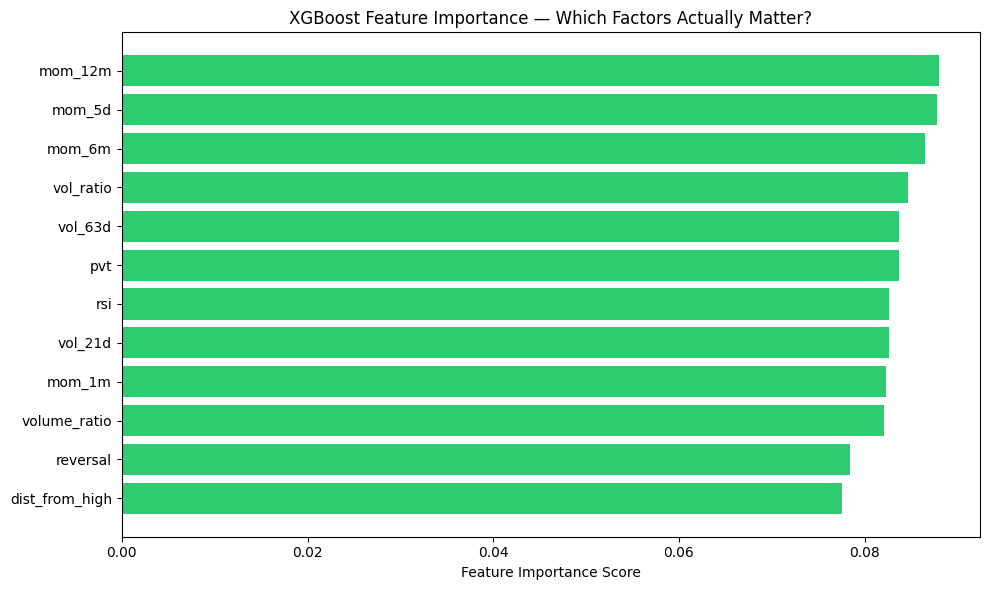

       feature  importance
       mom_12m    0.088029
        mom_5d    0.087826
        mom_6m    0.086475
     vol_ratio    0.084675
       vol_63d    0.083707
           pvt    0.083664
           rsi    0.082595
       vol_21d    0.082585
        mom_1m    0.082320
  volume_ratio    0.082136
      reversal    0.078444
dist_from_high    0.077544


In [6]:
last_model = all_predictions[-1]['model']

importance_df = pd.DataFrame({
    'feature':    FEATURES,
    'importance': last_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'], color='#2ecc71')
plt.xlabel('Feature Importance Score')
plt.title('XGBoost Feature Importance — Which Factors Actually Matter?')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importance_df.to_string(index=False))

In [7]:
def create_sequences(df, features, target_col, sequence_length=6):
    sequences = []
    targets   = []
    tickers   = []
    dates     = []
    
    for ticker in df['ticker'].unique():
        ticker_data = df[df['ticker'] == ticker].sort_values('date')
        
        X = ticker_data[features].values
        y = ticker_data[target_col].values
        d = ticker_data['date'].values
        
        for i in range(sequence_length, len(X)):
            sequences.append(X[i-sequence_length:i])
            targets.append(y[i])
            tickers.append(ticker)
            dates.append(d[i])
    
    return np.array(sequences), np.array(targets), tickers, dates

SEQ_LENGTH = 6

sequences, targets, seq_tickers, seq_dates = create_sequences(
    df, FEATURES, 'target', SEQ_LENGTH
)

print(f"Sequences shape: {sequences.shape}")
print(f"Targets shape:   {targets.shape}")
print(f"What this means: {sequences.shape[0]} samples, each with {sequences.shape[1]} months of {sequences.shape[2]} features")

Sequences shape: (37320, 6, 12)
Targets shape:   (37320,)
What this means: 37320 samples, each with 6 months of 12 features


In [8]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, dropout_rate):
        super(LSTMModel, self).__init__()
        
        self.lstm1   = nn.LSTM(input_size, hidden_size1, batch_first=True)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.lstm2   = nn.LSTM(hidden_size1, hidden_size2, batch_first=True)
        self.dropout2 = nn.Dropout(dropout_rate)
        self.fc      = nn.Linear(hidden_size2, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        out, _  = self.lstm1(x)
        out     = self.dropout1(out)
        out, _  = self.lstm2(out)
        out     = self.dropout2(out)
        out     = self.fc(out[:, -1, :])
        out     = self.sigmoid(out)
        return out.squeeze()

model_lstm = LSTMModel(
    input_size   = 12,
    hidden_size1 = 64,
    hidden_size2 = 32,
    dropout_rate = 0.3
)

print(model_lstm)
print(f"\nTotal parameters: {sum(p.numel() for p in model_lstm.parameters()):,}")

LSTMModel(
  (lstm1): LSTM(12, 64, batch_first=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (lstm2): LSTM(64, 32, batch_first=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Total parameters: 32,545


In [9]:
# Prepare data
scaler_lstm = StandardScaler()
sequences_scaled = scaler_lstm.fit_transform(
    sequences.reshape(-1, 12)
).reshape(-1, 6, 12)

split = int(len(sequences_scaled) * 0.8)

X_train = torch.FloatTensor(sequences_scaled[:split])
y_train = torch.FloatTensor(targets[:split])
X_test  = torch.FloatTensor(sequences_scaled[split:])
y_test  = torch.FloatTensor(targets[split:])

train_dataset = TensorDataset(X_train, y_train)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Training setup
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)

# Train
EPOCHS = 20
for epoch in range(EPOCHS):
    model_lstm.train()
    total_loss = 0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model_lstm(batch_X)
        loss        = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    if (epoch + 1) % 5 == 0:
        model_lstm.eval()
        with torch.no_grad():
            test_pred = model_lstm(X_test)
            test_pred_binary = (test_pred > 0.5).float()
            acc = accuracy_score(y_test.numpy(), test_pred_binary.numpy())
        print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(train_loader):.4f} | Test Accuracy: {acc*100:.1f}%")

print("\nLSTM Training Complete!")

Epoch 5/20 | Loss: 0.6927 | Test Accuracy: 52.0%
Epoch 10/20 | Loss: 0.6921 | Test Accuracy: 52.0%
Epoch 15/20 | Loss: 0.6907 | Test Accuracy: 52.0%
Epoch 20/20 | Loss: 0.6880 | Test Accuracy: 51.3%

LSTM Training Complete!


In [12]:
print("=" * 50)
print("   FINAL MODEL COMPARISON SUMMARY")
print("=" * 50)

xgb_acc = np.mean([p['accuracy'] for p in all_predictions])

model_lstm.eval()
with torch.no_grad():
    test_pred        = model_lstm(X_test)
    test_pred_binary = (test_pred > 0.5).float()
    lstm_acc         = accuracy_score(y_test.numpy(), test_pred_binary.numpy())

print(f"\n  XGBoost Accuracy:       {xgb_acc*100:.1f}%")
print(f"  LSTM Accuracy:          {lstm_acc*100:.1f}%")
print(f"  Random Baseline:        50.0%")
print(f"\n  Phase 3 Factor Model:   1,398.7% total return")
print(f"  SPY Benchmark:          251.0% total return")


   FINAL MODEL COMPARISON SUMMARY

  XGBoost Accuracy:       49.6%
  LSTM Accuracy:          51.3%
  Random Baseline:        50.0%

  Phase 3 Factor Model:   1,398.7% total return
  SPY Benchmark:          251.0% total return


## Key Findings — Phase 4: Machine Learning

### Model Performance
| Model | Accuracy | vs Random Baseline |
|---|---|---|
| XGBoost (Walk Forward) | 49.6% | -0.4% |
| LSTM Neural Network | 51.3% | +1.3% |
| Random Baseline | 50.0% | — |

### What The Data Tells Us

**Factor models work — ML classification doesn't (at this scale).**

The Phase 3 factor portfolio delivered 1,398% total returns versus SPY's 251% through systematic monthly rebalancing across 15 stocks. However both ML models hovered near 50% accuracy when predicting individual stock outperformance month to month.

Both results are consistent with a semi-efficient market where no single model can consistently predict individual returns.

### Limitations
- Universe of only 15 stocks limits ML sample size significantly
- Monthly prediction horizon may be too coarse for ML to find signal
- No fundamental data (earnings, revenue, debt) included as features
- Transaction costs and slippage not modeled